In [9]:
import pandas as pd

# Load the datasets from the specified paths
df_corona = pd.read_csv("../data cleanup/sars_cov2_cdr_seq.tsv", sep="\t")
df_human = pd.read_csv("../data cleanup/human_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("../data cleanup/influenza_cdr_seq.tsv", sep="\t")




In [ ]:
from collections import Counter
import pandas as pd

from collections import Counter

def aa_composition(seq):
    if not isinstance(seq, str) or not seq:
        return {aa: 0 for aa in "ACDEFGHIKLMNPQRSTVWY"}
    total = len(seq)
    counts = Counter(seq)
    return {aa: counts.get(aa, 0) / total for aa in "ACDEFGHIKLMNPQRSTVWY"}


# Für SARS
aac_sars = df_corona["CDR_H3"].apply(aa_composition).apply(pd.Series)
aac_sars["group"] = "Corona"

# Für Influenza
aac_influenza = df_influenza["CDR_H3"].apply(aa_composition).apply(pd.Series)
aac_influenza["group"] = "Influenza"

# Für Human
aac_human = df_human["CDR_H3"].apply(aa_composition).apply(pd.Series)
aac_human["group"] = "Human"



In [12]:
# Gruppierte Mittelwerte berechnen
mean_sars = aac_sars.drop(columns="group").mean()
mean_influenza = aac_influenza.drop(columns="group").mean()
mean_human = aac_human.drop(columns="group").mean()


In [13]:
df_plot = pd.DataFrame({
    "AminoAcid": mean_sars.index,
    "Corona": mean_sars.values,
    "Influenza": mean_influenza.values,
    "Human": mean_human.values
})

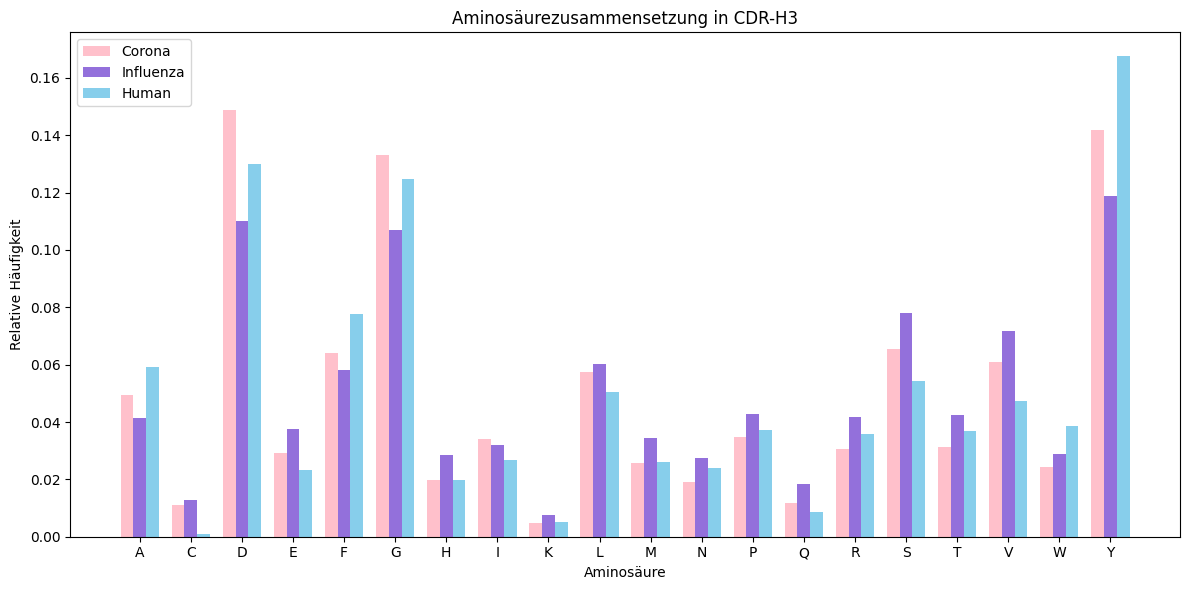

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Balken nebeneinander setzen
x = np.arange(len(df_plot["AminoAcid"]))  # Positionen auf x-Achse
width = 0.25  # Breite der Balken

plt.figure(figsize=(12, 6))
plt.bar(x - width, df_plot["Corona"], width=width, label="Corona", color="pink")
plt.bar(x,         df_plot["Influenza"], width=width, label="Influenza", color="mediumpurple")
plt.bar(x + width, df_plot["Human"], width=width, label="Human", color="skyblue")

# Achsenbeschriftung
plt.xticks(ticks=x, labels=df_plot["AminoAcid"])
plt.ylabel("Relative Häufigkeit")
plt.xlabel("Aminosäure")
plt.title("Aminosäurezusammensetzung in CDR-H3")
plt.legend()
plt.tight_layout()
plt.show()
